In [1]:
import pandas as pd

# CSV 불러오기
df = pd.read_csv('지역 기반 혜택·정보 공유 서비스 「기특기특(가칭)」 설문조사.csv')

# 컬럼 공백 제거
df.columns = df.columns.str.strip()

# 확인
print(f'응답자 수: {len(df)}명')
print(f'컬럼 수: {len(df.columns)}개')

응답자 수: 182명
컬럼 수: 22개


In [2]:
[col for col in df.columns if 'Q6' in col]

['Q6. 주로 활동하는 지역을 선택해주세요.']

In [3]:
[col for col in df.columns if 'Q1' in col]

['Q1. 연령대를 선택해주세요.',
 'Q10. 가성비 정보나 할인 정보를 주로 어디서 찾으시나요? (복수 선택)',
 'Q11. 생활비 절약·정보 공유 서비스 중 사용해본 경험이 있는 서비스를 모두 선택해주세요. (복수 선택)',
 'Q12. 생활비 절약 정보를 한 곳에서 확인할 수 있는 서비스가 있다면 이용할 의향이 있으신가요?',
 'Q13. 식당(맛집, 카페, 술집 포함)외 필요하다고 생각하는 정보를 선택해주세요.(복수선택)',
 'Q14. 지도 기반으로 절약 정보를 제공하는 서비스에 대해 얼마나 매력을 느끼시나요?',
 'Q15. 절약 정보를 찾을 때 가장 중요하게 생각하는 것은 무엇인가요?',
 'Q16. 아래 기능 중 가장 사용해보고 싶은 기능은 무엇인가요?',
 'Q17. 공동구매 서비스에 관심이 있으신가요?',
 'Q18. 공동구매 서비스에 참여한다면 어떤 제품을 희망하시나요?  (복수선택)',
 'Q19. 온라인 커뮤니티에 직접 게시글 작성, 댓글 작성, 정보 공유를 해본 경험이 있으신가요?']

In [5]:
# 30대 응답자만 추출
df_30s = df[df['Q1. 연령대를 선택해주세요.'] == '30대']

# 30대 응답자의 활동지역 집계
area_30s = df_30s['Q6. 주로 활동하는 지역을 선택해주세요.'].value_counts()

area_30s_df = pd.DataFrame({
    '응답수': area_30s,
    '비율(%)': round(area_30s / len(df_30s) * 100, 1)
})

area_30s_df

,응답수,비율(%)
Q6. 주로 활동하는 지역을 선택해주세요.,,
"서울 강북권 (노원구, 성동구, 중랑구, 마포구 등)",17,24.6
"서울 강남권 (강남구, 서초구, 송파구)",11,15.9
"경기 북부 (고양시, 남양주시, 구리시, 파주시 등)",8,11.6
"경기 남부 (수원시, 용인시, 성남시, 안산시)",7,10.1
인천,5,7.2
경남,3,4.3
강원,2,2.9
부산,2,2.9
대전,1,1.4


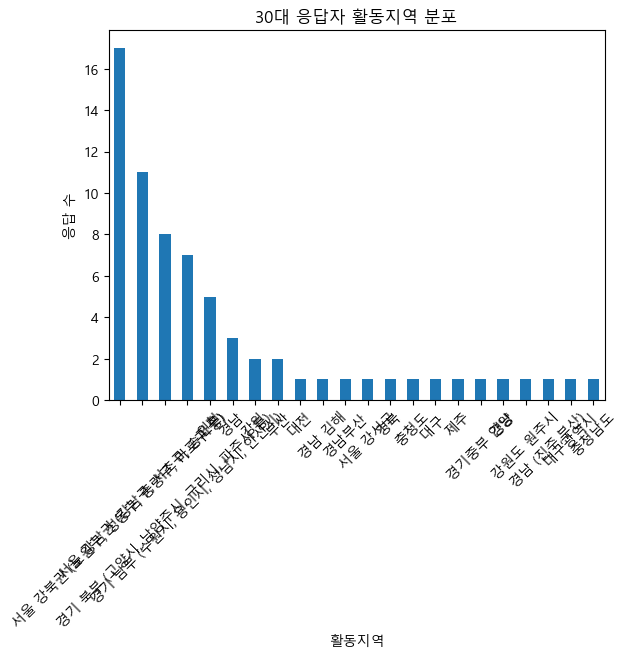

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

area_30s.plot(kind='bar')

plt.title('30대 응답자 활동지역 분포')
plt.xlabel('활동지역')
plt.ylabel('응답 수')
plt.xticks(rotation=45)

plt.show()

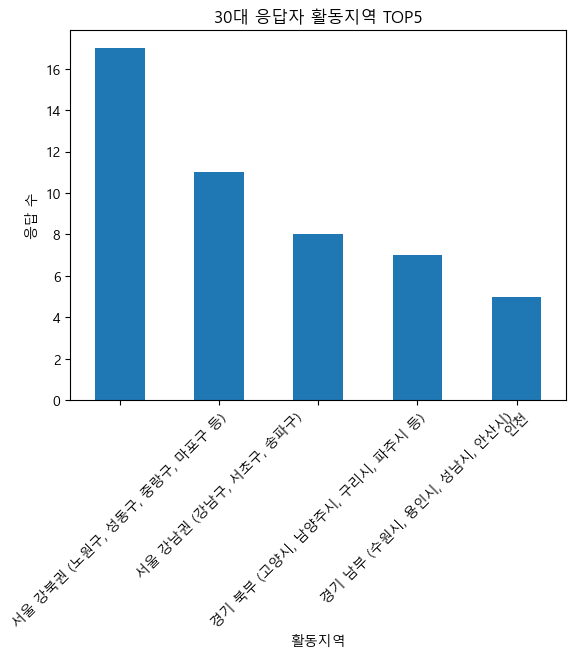

In [7]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# TOP5만 추출
area_30s_top5 = area_30s.head(5)

area_30s_top5.plot(kind='bar')

plt.title('30대 응답자 활동지역 TOP5')
plt.xlabel('활동지역')
plt.ylabel('응답 수')
plt.xticks(rotation=45)

plt.show()


In [9]:
[col for col in df.columns if 'Q13' in col]

['Q13. 식당(맛집, 카페, 술집 포함)외 필요하다고 생각하는 정보를 선택해주세요.(복수선택)']

In [10]:
# 30대만 추출
df_30s = df[df['Q1. 연령대를 선택해주세요.'] == '30대']

# Q13 복수응답 분리
q13 = (
    df_30s['Q13. 식당(맛집, 카페, 술집 포함)외 필요하다고 생각하는 정보를 선택해주세요.(복수선택)']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
)

# 집계
q13_result = q13.value_counts()

# 데이터프레임 생성
q13_df = pd.DataFrame({
    '응답수': q13_result,
    '비율(%)': round(q13_result / len(df_30s) * 100, 1)
})

q13_df

,응답수,비율(%)
"Q13. 식당(맛집, 카페, 술집 포함)외 필요하다고 생각하는 정보를 선택해주세요.(복수선택)",,
문화생활 할인 정보,48,69.6
미용 할인 정보,37,53.6
편의점 행사 정보,37,53.6
세탁/생활서비스 정보,35,50.7
공동구매 정보,29,42.0


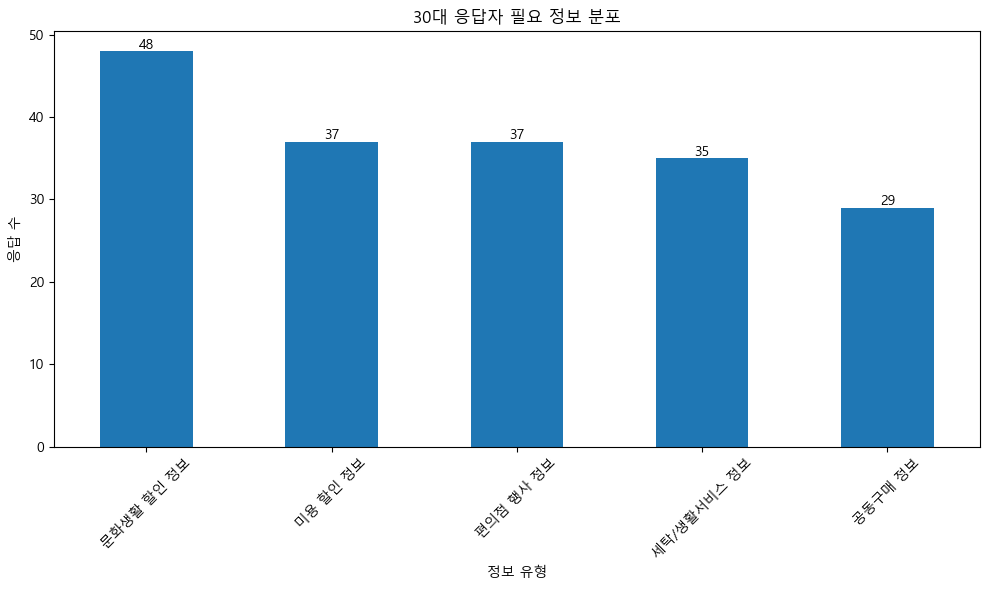

In [12]:
import matplotlib.pyplot as plt

# 30대만 추출
df_30s = df[df['Q1. 연령대를 선택해주세요.'] == '30대']

# Q13 복수응답 분리
q13 = (
    df_30s['Q13. 식당(맛집, 카페, 술집 포함)외 필요하다고 생각하는 정보를 선택해주세요.(복수선택)']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
)

q13_result = q13.value_counts()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

q13_result.plot(kind='bar')

plt.title('30대 응답자 필요 정보 분포')
plt.xlabel('정보 유형')
plt.ylabel('응답 수')

plt.xticks(rotation=45)

# 수치 표시
for i, v in enumerate(q13_result.values):
    plt.text(i, v + 0.3, str(v), ha='center')

plt.tight_layout()
plt.show()

In [13]:
# 30대만 추출
df_30s = df[df['Q1. 연령대를 선택해주세요.'] == '30대']

for col in df_30s.columns:
    print(f'\n{"="*50}')
    print(col)

    try:
        result = df_30s[col].value_counts(dropna=False).head(5)

        result_df = pd.DataFrame({
            '응답수': result,
            '비율(%)': round(result / len(df_30s) * 100, 1)
        })

        print(result_df)

    except:
        pass


타임스탬프
                             응답수  비율(%)
타임스탬프                                  
2026/06/12 3:48:07 오후 GMT+9    1    1.4
2026/06/12 3:48:50 오후 GMT+9    1    1.4
2026/06/12 5:19:20 오후 GMT+9    1    1.4
2026/06/12 5:44:10 오후 GMT+9    1    1.4
2026/06/12 6:09:29 오후 GMT+9    1    1.4

[개인정보 수집 및 이용 동의] 
본 설문조사를 통해 수집된 개인정보 및 응답 내용은 「기특기특(가칭)」 서비스 기획 및 사용자 요구사항 분석을 위한 연구 목적으로만 활용됩니다.

수집 항목: 성별, 연령대, 직업, 활동 지역, 생활비 절약 정보 이용 행태, 지역 정보 공유 서비스 이용 경험, 설문 응답 내용, 이메일(선택)
보유 기간: 수집일로부터 1개월

수집된 개인정보는 연구 및 서비스 기획 목적 외에는 사용되지 않으며, 보유 기간 종료 후 안전하게 파기됩니다.
귀하는 개인정보 수집 및 이용에 대한 동의를 거부할 권리가 있습니다. 다만, 동의를 거부할 경우 설문 참여가 제한될 수 있습니다.
-----------------------------

  ※ 설문 마지막에 입력하신 이메일 주소는 서비스 출시 안내, 베타테스트 참여 안내 및 이벤트 공지 목적으로만 활용되며, 해당 목적 외에는 사용되지 않습니다.
                                                    응답수  비율(%)
[개인정보 수집 및 이용 동의] \n본 설문조사를 통해 수집된 개인정보 및 응답 내용...            
[필수] 개인정보 수집 및 이용에 동의합니다                             67   97.1
NaN                                                   2    2.9

Q